<a href="https://colab.research.google.com/github/wjdwogns2873-web/deep-learning-study/blob/main/Kaggle_Study_Practice/02_Digit_Recognizer_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. 구글 드라이브 연결 (로그인 팝업이 뜨면 확인만 눌러주세요)
from google.colab import drive
drive.mount('/content/drive')

# 2. 구글 드라이브에 저장해둔 열쇠(access_token)를 코랩 보안 폴더로 자동 복사
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/Kaggle/access_token ~/.kaggle/
!chmod 600 ~/.kaggle/access_token

Mounted at /content/drive


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('digit-recognizer')

print("Path to competition files:", path)

100%|██████████| 15.3M/15.3M [00:00<00:00, 16.4MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/digit-recognizer


In [ ]:
import os
for dirname, _, filenames in os.walk('/root/.cache/kagglehub/competitions/digit-recognizer'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/root/.cache/kagglehub/competitions/digit-recognizer/test.csv
/root/.cache/kagglehub/competitions/digit-recognizer/sample_submission.csv
/root/.cache/kagglehub/competitions/digit-recognizer/train.csv


In [ ]:
import torch
import numpy as np
import pandas as pd

train_df = pd.read_csv('/root/.cache/kagglehub/competitions/digit-recognizer/train.csv')

train_labels = train_df['label'].values
train_images = train_df.drop('label', axis=1).values

print(f"labels.shape: {train_labels.shape} | images.shape: {train_images.shape}")

labels.shape: (42000,) | images.shape: (42000, 784)


In [ ]:
X_tensor = torch.FloatTensor(train_images) # 많은 자료형 중에서 FloatTensor로 바꾸는 이유?
y_tensor = torch.LongTensor(train_labels)

X_tensor = X_tensor.view(-1, 1, 28, 28)
print(X_tensor.shape, y_tensor.shape)

torch.Size([42000, 1, 28, 28]) torch.Size([42000])


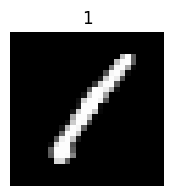

In [ ]:
# @title
import matplotlib.pyplot as plt
image_index = 0

sample_image = X_tensor[image_index].squeeze().numpy()
sample_label = y_tensor[image_index].item()

plt.figure(figsize=(4, 2))

plt.imshow(sample_image, cmap='gray')
plt.title(sample_label)
plt.axis('off')
plt.show()

In [ ]:
from torch.utils.data import Dataset, DataLoader

class MNISTDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        image = self.images[idx]
        label = self.labels[idx]
        return image, label

train_dataset = MNISTDataset(X_tensor, y_tensor)
print(len(train_dataset))

42000


In [ ]:
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

print(len(train_loader))

657


In [ ]:
batch_images, batch_labels = next(iter(train_loader))
print(batch_images.shape)
print(batch_labels.shape)

torch.Size([64, 1, 28, 28])
torch.Size([64])


In [ ]:
import torch.nn as nn
import torch.nn.functional as F

class MNISTCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.drop1 = nn.Dropout(0.25)

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.drop2 = nn.Dropout(0.25)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.bn5 = nn.BatchNorm1d(128)
        self.drop3 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)
    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.drop1(self.pool1(x))

        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.drop2(self.pool2(x))

        x = x.view(x.size(0), -1)
        x = F.relu(self.bn5(self.fc1(x)))
        x = self.drop3(x)
        x = self.fc2(x)

        return x

model = MNISTCNN()
print(model)

MNISTCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (bn5):

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
test_output = model(batch_images)
print(test_output.shape)

torch.Size([64, 10])


In [ ]:
import torch.optim as optim
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {device}")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

device: cuda


In [ ]:
def train_model(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        pred = model(images)
        loss = criterion(pred, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = pred.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if (batch_idx + 1) % 100 == 0:
            print(f"Batch {batch_idx + 1}/{len(train_loader)} | "
                  f"Loss: {running_loss/(batch_idx + 1):.4f} | "
                  f"Accuracy: {100 * correct / total:.2f}%")

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total
    return epoch_loss, epoch_acc

In [ ]:
epoch_loss, epoch_acc = train_model(model, train_loader, criterion, optimizer, device)
print(f"Epoch Loss: {epoch_loss} | Epoch Accuracy: {epoch_acc}")

Batch 100/657 | Loss: 0.5772 | Accuracy: 87.42%
Batch 200/657 | Loss: 0.3871 | Accuracy: 91.61%
Batch 300/657 | Loss: 0.3039 | Accuracy: 93.27%
Batch 400/657 | Loss: 0.2543 | Accuracy: 94.25%
Batch 500/657 | Loss: 0.2242 | Accuracy: 94.89%
Batch 600/657 | Loss: 0.2029 | Accuracy: 95.27%
Epoch Loss: 0.1921421342488248 | Epoch Accuracy: 95.48333333333333


In [ ]:
EPOCHS = 2
history_loss = []
history_acc = []

for epoch in range(EPOCHS):
    print(f"=== Epoch {epoch+1}/{EPOCHS} ===")
    epoch_loss, epoch_acc = train_model(model, train_loader, criterion, optimizer, device)
    history_loss.append(epoch_loss)
    history_acc.append(epoch_acc)
    print(f"Epoch {epoch+1} 마감 결과 | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%\n")


=== Epoch 1/2 ===
Batch 100/657 | Loss: 0.0735 | Accuracy: 98.02%
Batch 200/657 | Loss: 0.0698 | Accuracy: 98.16%
Batch 300/657 | Loss: 0.0698 | Accuracy: 98.18%
Batch 400/657 | Loss: 0.0688 | Accuracy: 98.17%
Batch 500/657 | Loss: 0.0689 | Accuracy: 98.15%
Batch 600/657 | Loss: 0.0682 | Accuracy: 98.15%
Epoch 1 마감 결과 | Loss: 0.0679 | Accuracy: 98.15%

=== Epoch 2/2 ===
Batch 100/657 | Loss: 0.0499 | Accuracy: 98.52%
Batch 200/657 | Loss: 0.0569 | Accuracy: 98.29%
Batch 300/657 | Loss: 0.0519 | Accuracy: 98.46%
Batch 400/657 | Loss: 0.0522 | Accuracy: 98.43%
Batch 500/657 | Loss: 0.0534 | Accuracy: 98.40%
Batch 600/657 | Loss: 0.0519 | Accuracy: 98.46%
Epoch 2 마감 결과 | Loss: 0.0523 | Accuracy: 98.45%



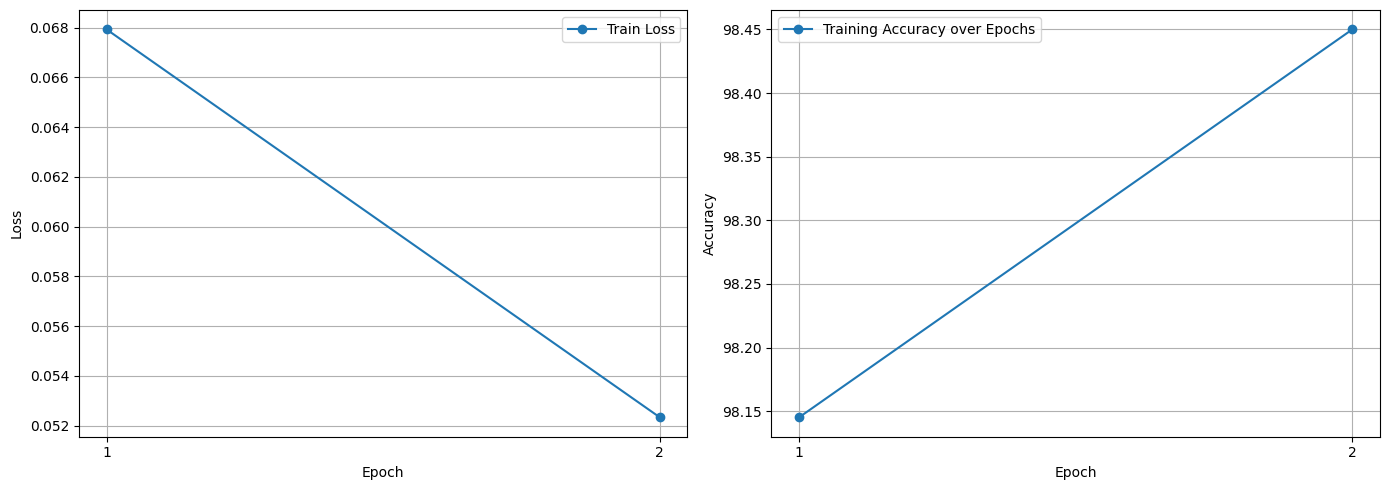

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(range(1, len(history_loss) + 1), history_loss, marker='o', label='Train Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True)
ax1.set_xticks(range(1, len(history_loss) + 1))
ax1.legend()

ax2.plot(range(1, len(history_acc) + 1), history_acc, marker='o', label='Training Accuracy over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.grid(True)
ax2.set_xticks(range(1, len(history_acc) + 1))
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
test_df = pd.read_csv('/root/.cache/kagglehub/competitions/digit-recognizer/test.csv')
# .values를 붙여서 순수한 넘파이 배열로 변환.
test_images = test_df.values

X_test_tensor = torch.FloatTensor(test_images)
X_test_tensor = X_test_tensor.view(-1, 1, 28, 28)

model.eval()
predictions = []

with torch.no_grad():
    X_test_tensor = X_test_tensor.to(device)
    outputs = model(X_test_tensor)

    # print(outputs.max(1).shape)

    _, predicted = outputs.max(1)

    predictions = predicted.cpu().numpy()

submission = pd.DataFrame({
    "ImageId": range(1, len(predictions) + 1),
    "Label": predictions
})

